In [1]:
# Import Libraries and modules

# libraries that are used for analysis and visualization

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Impoting data preprocessing libraries
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [3]:
# Importing model selection libraries.
from sklearn.model_selection import train_test_split


In [4]:
# Importing metrics for model evaluation.
from sklearn.metrics import confusion_matrix, accuracy_score

In [5]:
# Importing machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

load the CARDIOVASCULAR RISK DATA

In [6]:
#Dataset First View
risk_df=pd.read_csv('cardiovascular_risk_data.csv',na_values=["NA", "N/A", "null", "None", "?", "-"])

# Viewing the top 5 rows to take a glimpse of the data
risk_df.head(5)

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


In [7]:
# Viewing the last 5 rows
risk_df.tail(5)

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
3385,3385,60,1.0,F,NO,0.0,0.0,0,0,0,261.0,123.5,79.0,29.28,70.0,103.0,0
3386,3386,46,1.0,F,NO,0.0,0.0,0,0,0,199.0,102.0,56.0,21.96,80.0,84.0,0
3387,3387,44,3.0,M,YES,3.0,0.0,0,1,0,352.0,164.0,119.0,28.92,73.0,72.0,1
3388,3388,60,1.0,M,NO,0.0,NaN,0,1,0,191.0,167.0,105.0,23.01,80.0,85.0,0
3389,3389,54,3.0,F,NO,0.0,0.0,0,0,0,288.0,124.0,77.0,29.88,79.0,92.0,0


In [8]:
# Dataset Rows & Columns 
risk_df.shape

(3390, 17)

In [9]:
print(f'number of rows : {risk_df.shape[0]}  \nnumber of columns : {risk_df.shape[1]}')

number of rows : 3390  
number of columns : 17


### Dataset Information

In [10]:
risk_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               3390 non-null   int64  
 1   age              3390 non-null   int64  
 2   education        3303 non-null   float64
 3   sex              3390 non-null   str    
 4   is_smoking       3390 non-null   str    
 5   cigsPerDay       3368 non-null   float64
 6   BPMeds           3346 non-null   float64
 7   prevalentStroke  3390 non-null   int64  
 8   prevalentHyp     3390 non-null   int64  
 9   diabetes         3390 non-null   int64  
 10  totChol          3352 non-null   float64
 11  sysBP            3390 non-null   float64
 12  diaBP            3390 non-null   float64
 13  BMI              3376 non-null   float64
 14  heartRate        3389 non-null   float64
 15  glucose          3086 non-null   float64
 16  TenYearCHD       3390 non-null   int64  
dtypes: float64(9), int64(6), 

## Duplicate Values

### How important is it to get rid of duplicate records in my data?

The mere presence of repeated data in the dataset is referred to as "duplication." This could be caused by incorrect data entry or procedures for collecting data. We can save time and money by not sending the same data to the machine learning model multiple times by removing duplicate data from our set.

In [11]:
# Checking Duplicate Values
risk_df.duplicated().sum()

np.int64(0)

Insight: We found that there were no duplicate entries in the above data.

## Missing Values/Null Values

### Why dealing with missing values is necessary?
There are frequently a lot of missing values in the actual data. Corrupted or missing data may result in missing values. Since many machine-learning algorithms do not support missing values, missing data must be handled during the dataset's pre-processing. Therefore, we begin by looking for values that are missing.

In [12]:
# Missing Values/Null Values Count
risk_df.isnull().sum()

id                   0
age                  0
education           87
sex                  0
is_smoking           0
cigsPerDay          22
BPMeds              44
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             38
sysBP                0
diaBP                0
BMI                 14
heartRate            1
glucose            304
TenYearCHD           0
dtype: int64

Insight: We can see there are null values present in totChol, BMI, glucose, BPMeds, cigsPerDay, education has some null values and heartRate has 1 null value.

In [13]:
# Missing Values Percentage
round(risk_df.isnull().sum()/len(risk_df)*100,2)

id                 0.00
age                0.00
education          2.57
sex                0.00
is_smoking         0.00
cigsPerDay         0.65
BPMeds             1.30
prevalentStroke    0.00
prevalentHyp       0.00
diabetes           0.00
totChol            1.12
sysBP              0.00
diaBP              0.00
BMI                0.41
heartRate          0.03
glucose            8.97
TenYearCHD         0.00
dtype: float64

### Insight: glucose column has significant number of missing values

<Axes: >

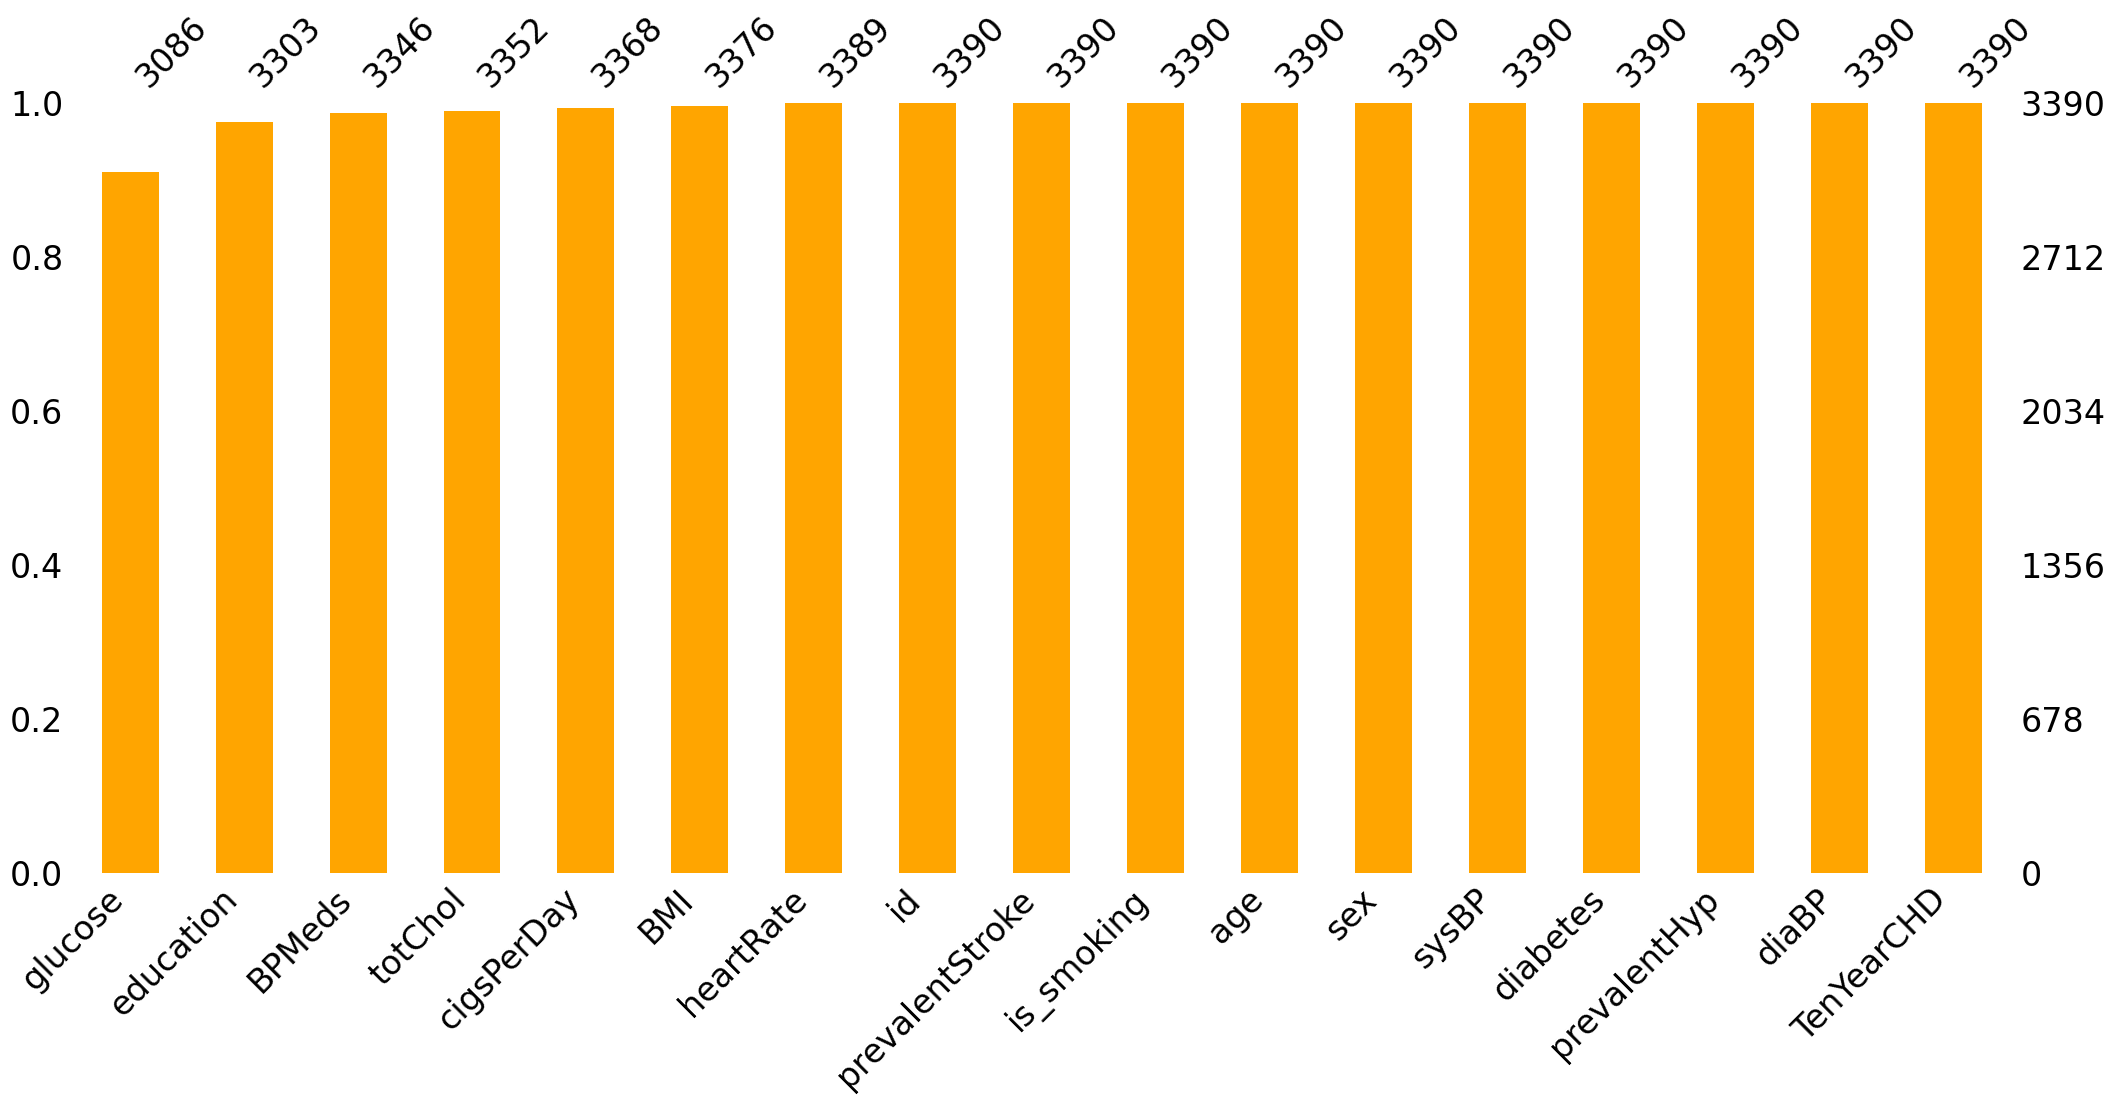

In [14]:
# Visualizing the missing values
import missingno as msno
msno.bar(risk_df,color='orange',sort='ascending',fontsize=24)

<Axes: >

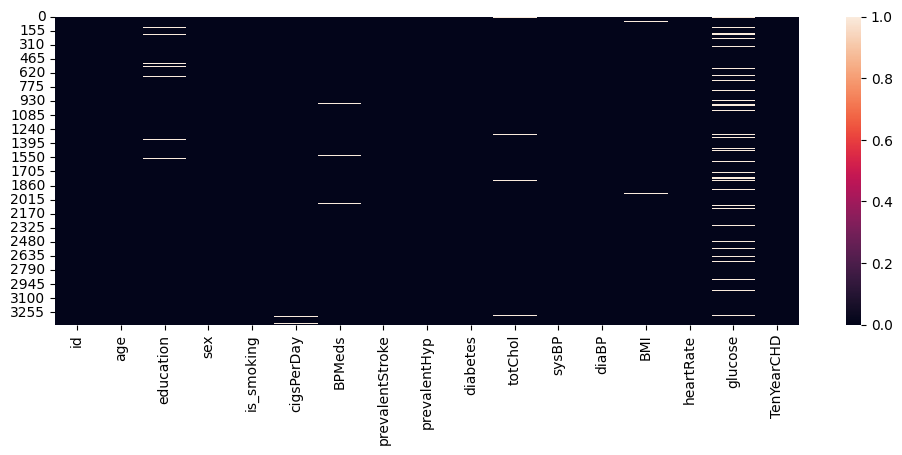

In [15]:
# Visualizing the missing values using Heatmap
plt.figure(figsize=(12,4))
sns.heatmap(risk_df.isna())

### Insight: There is no relation between any columns for missingness
if there would be same pattern for white lines in heatmap then it means two columns missingness have same relation, also if white lines are clustered in some part of a column then we say it is not MCAR but MAR or MNAR and data may be time-ordered or rows represents specific subgroups or dataset made by merging data